<a href="https://colab.research.google.com/github/madaam99/EnergyGermany/blob/main/SMARD_EDA_monthly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

In [2]:
upload = files.upload()

Saving processedVerbrauchMonthly to processedVerbrauchMonthly
Saving processedInstalledEnergy to processedInstalledEnergy
Saving processedErzeugungMonthly to processedErzeugungMonthly


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
instEnergy = pd.read_csv("/content/processedInstalledEnergy")
erzeugung = pd.read_csv("/content/processedErzeugungMonthly")
verbrauch = pd.read_csv("/content/processedVerbrauchMonthly")

In [5]:
instEnergy['Datum von'] = pd.to_datetime(instEnergy['Datum von'])
instEnergy['Datum bis'] = pd.to_datetime(instEnergy['Datum bis'])

erzeugung['Datum von'] = pd.to_datetime(erzeugung['Datum von'])
erzeugung['Datum bis'] = pd.to_datetime(erzeugung['Datum bis'])

verbrauch['Datum von'] = pd.to_datetime(verbrauch['Datum von'])
verbrauch['Datum bis'] = pd.to_datetime(verbrauch['Datum bis'])

Installed Energy

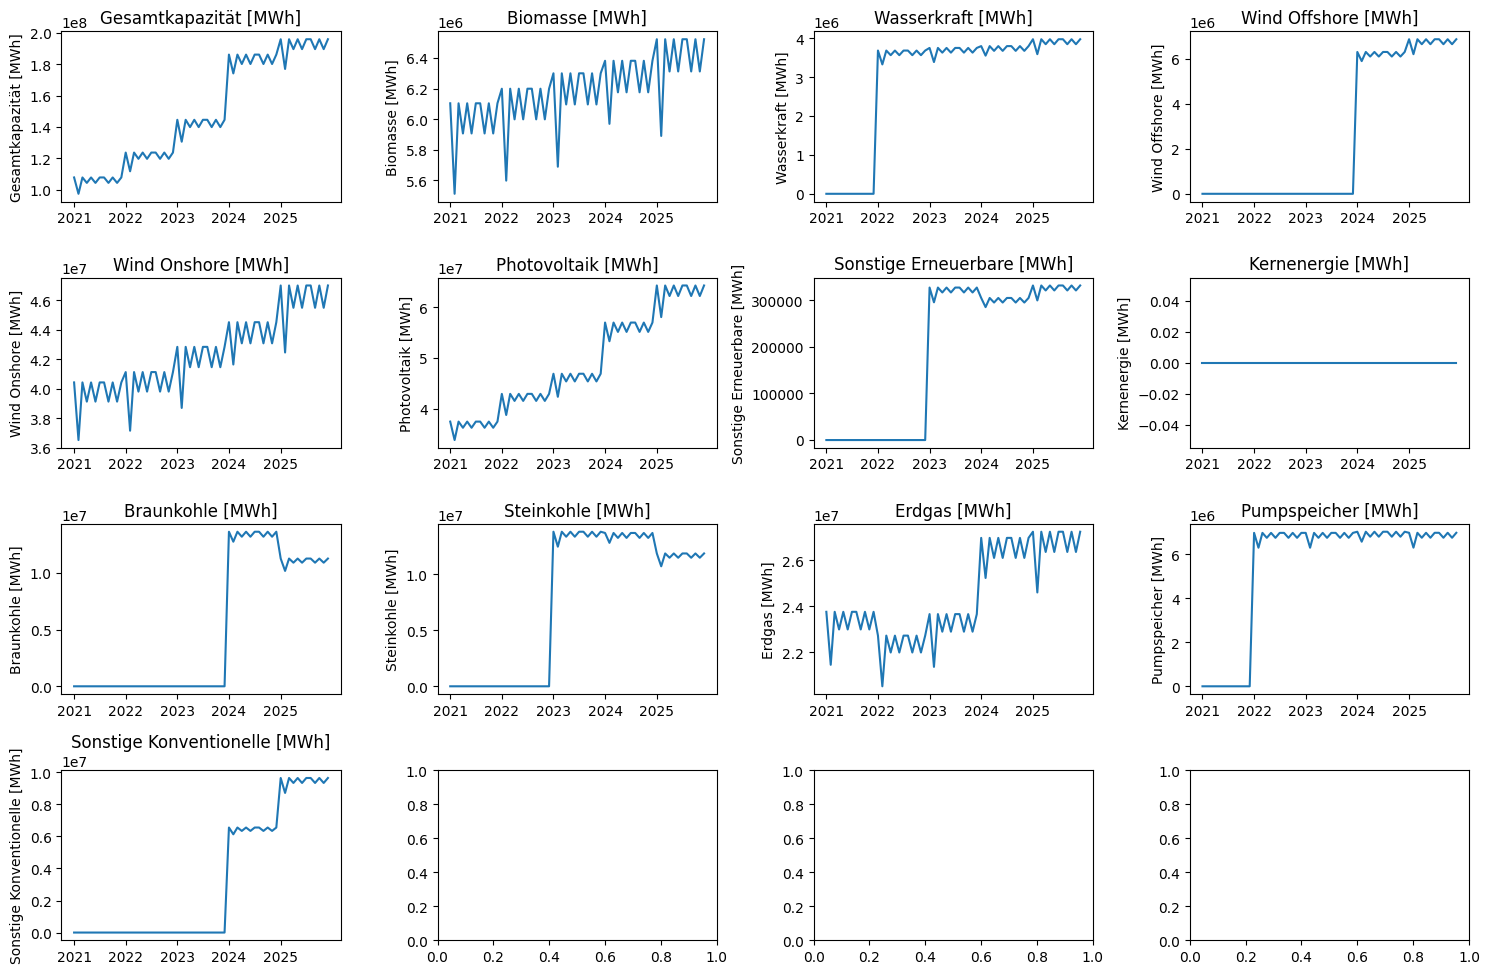

In [6]:
unique_years = instEnergy['Datum von'].dt.year.unique()
tick_location = [pd.to_datetime(f"{year}-01-01") for year in unique_years]
tick_label = unique_years

plotCol = instEnergy.columns.drop(["Datum von", "Datum bis"])

fig, ax = plt.subplots(4, 4, figsize=(15, 10))
ax = ax.flatten()

for i, col in enumerate(plotCol):
  sns.lineplot(data=instEnergy, x="Datum von", y=col, ax=ax[i])
  ax[i].set_xlabel("")
  ax[i].set_title(col)
  ax[i].set_xticks(tick_location, tick_label)

plt.tight_layout()
plt.show()

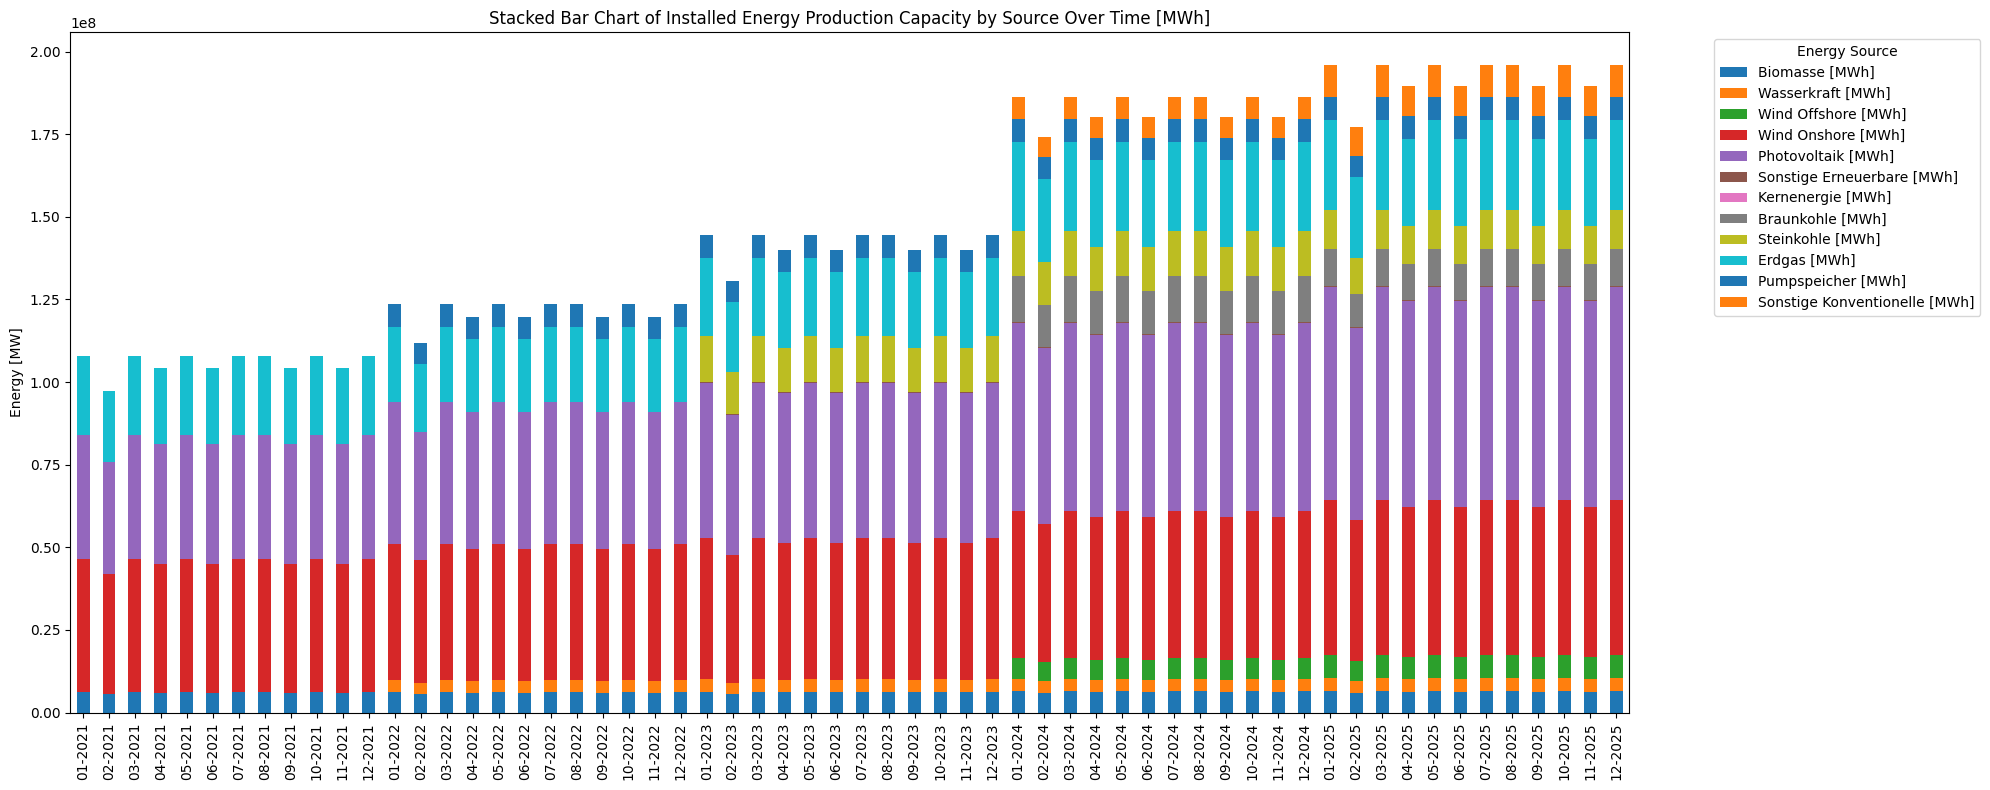

In [7]:
df_plot = instEnergy.set_index("Datum von")
stackCols = df_plot.columns.drop(["Datum bis", "Gesamtkapazität [MWh]"])

allMonthYearLabel = list(df_plot.index.strftime("%m-%Y"))
allTickLocations = list(range(len(allMonthYearLabel)))

fig, ax = plt.subplots(figsize=(20, 8))
df_plot[stackCols].plot(kind="bar", stacked=True, ax=ax)

ax.set_xticks(allTickLocations, allMonthYearLabel)
ax.set_title("Stacked Bar Chart of Installed Energy Production Capacity by Source Over Time [MWh]")
ax.set_ylabel('Energy [MW]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Produced Energy

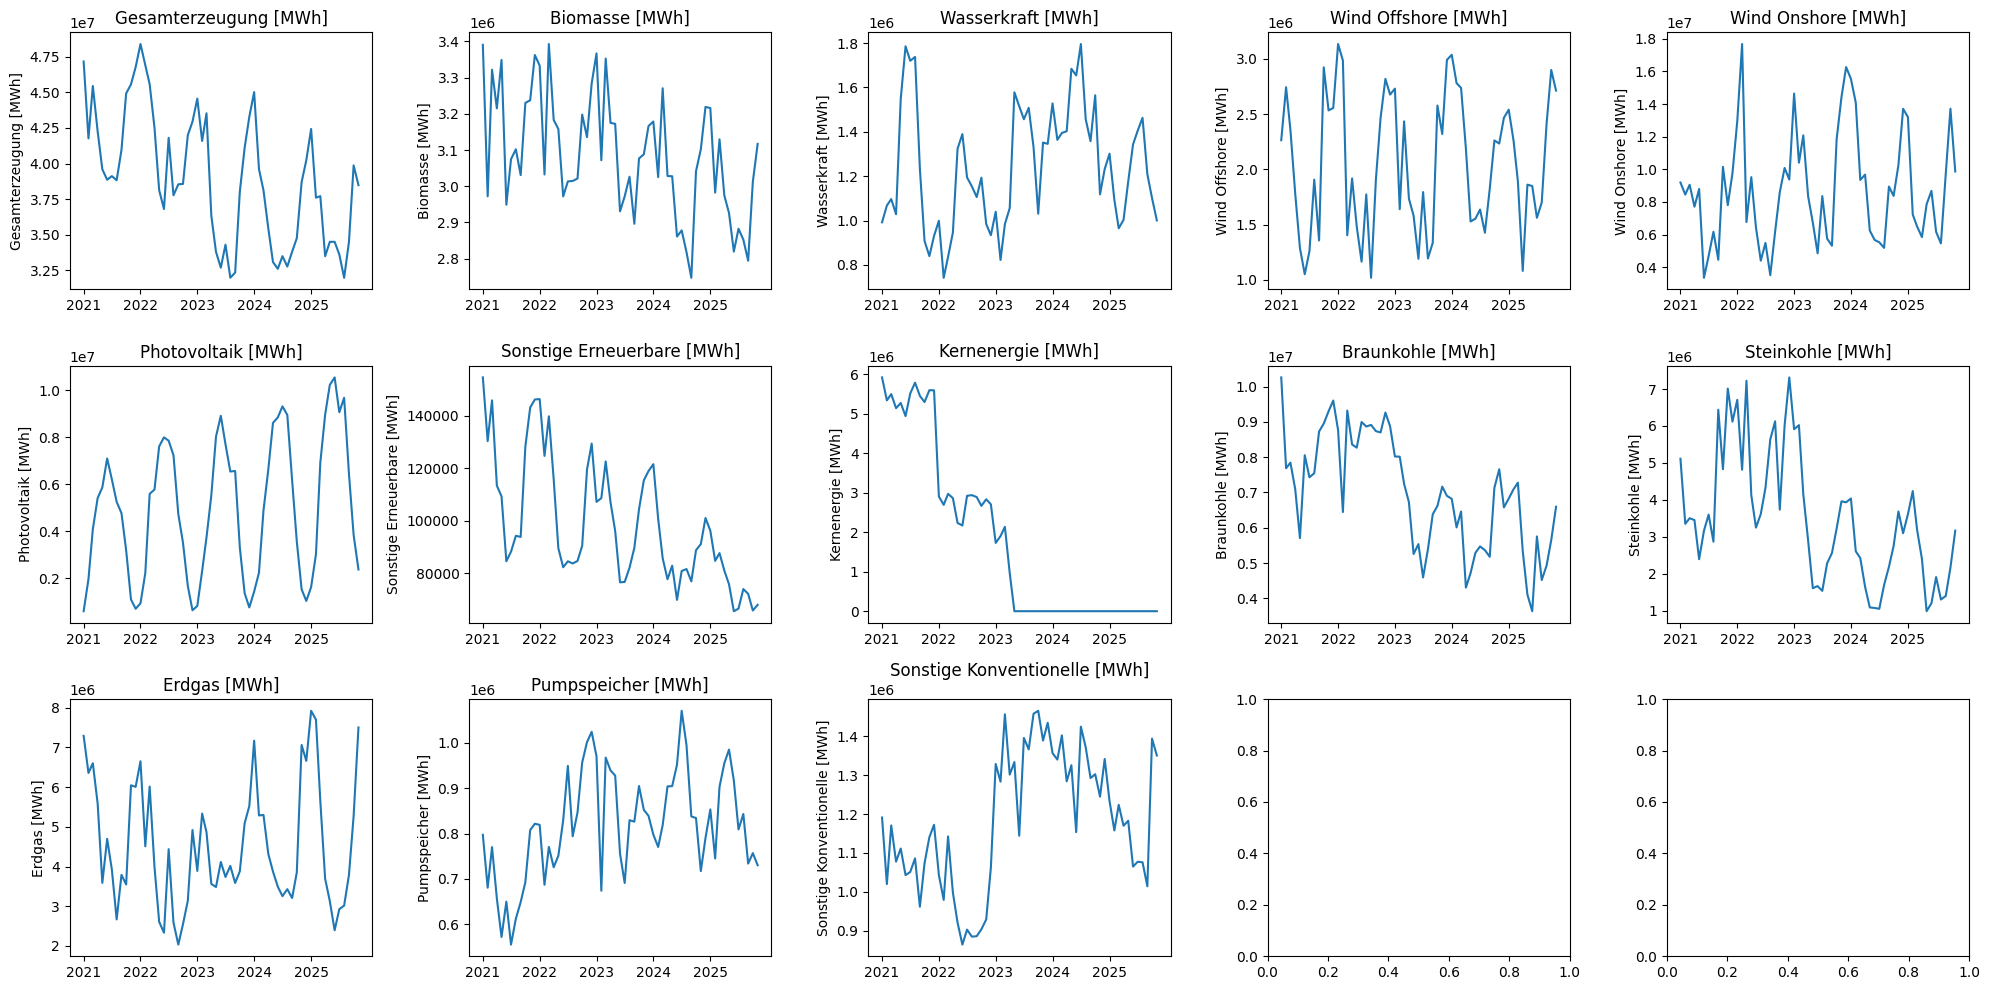

In [8]:
colsPlot = erzeugung.columns.drop(["Datum von", "Datum bis"])

fig, ax = plt.subplots(3, 5, figsize=(20, 10))
ax = ax.flatten()

unique_years = erzeugung['Datum von'].dt.year.unique()
tickLocations = [pd.to_datetime(f'{year}-01-01') for year in unique_years]
tickLabels = unique_years

for i, col in enumerate(colsPlot):
  sns.lineplot(data=erzeugung, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xticks(tickLocations, tickLabels)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

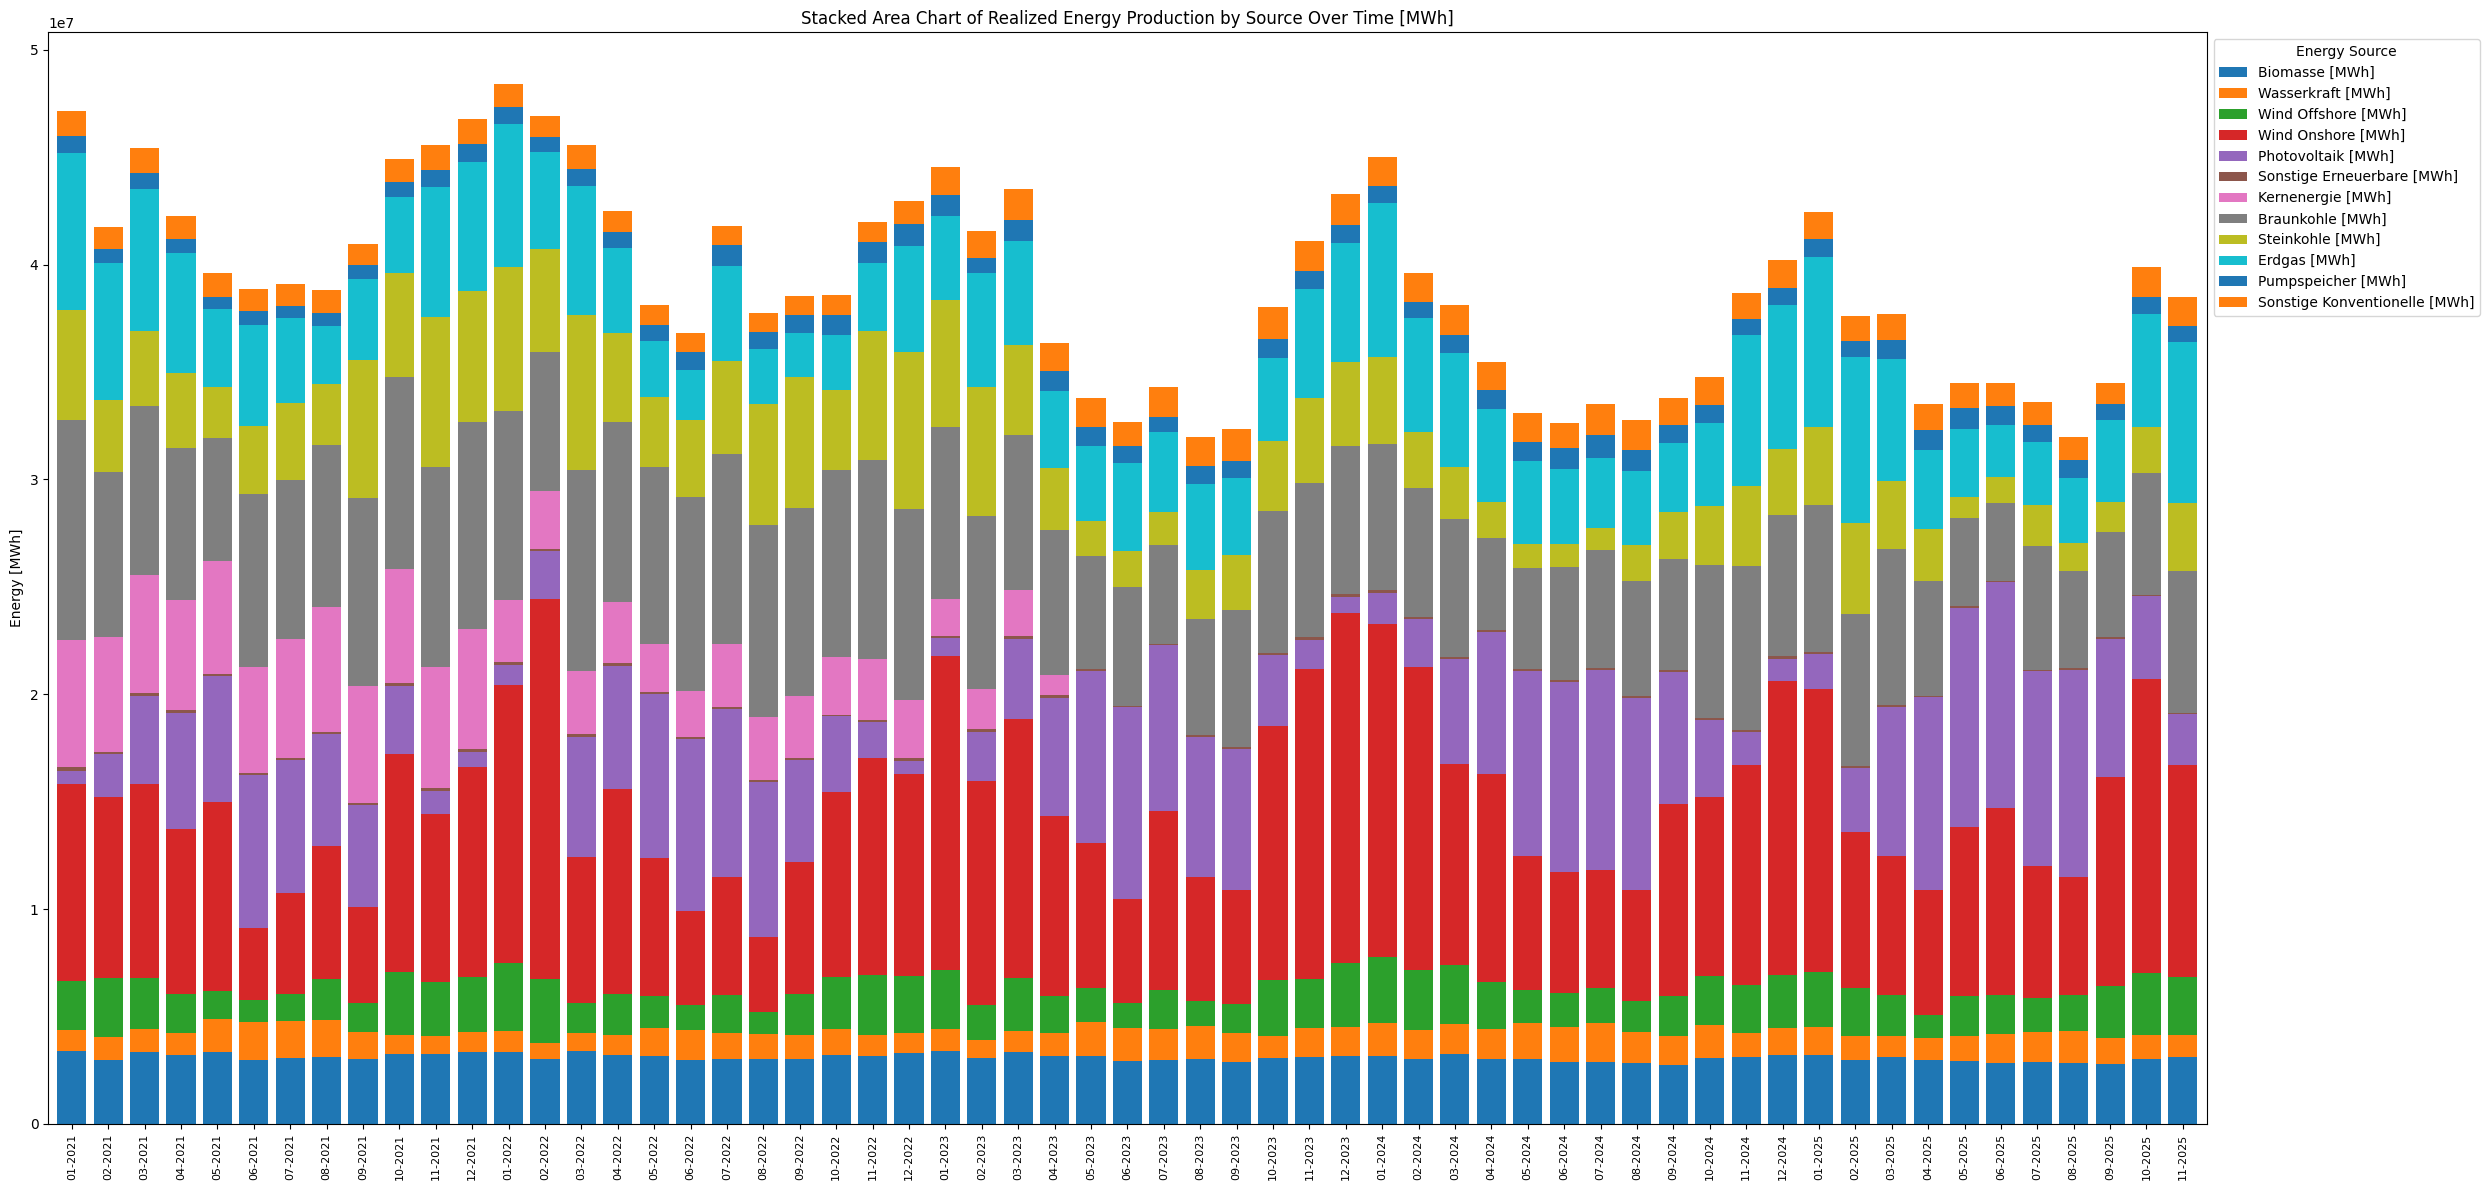

In [9]:
erzeugungPlotDf = erzeugung.set_index("Datum von")
stackCols = erzeugungPlotDf.columns.drop(["Datum bis", "Gesamterzeugung [MWh]"])

tickLabels = erzeugungPlotDf.index.strftime("%m-%Y")

fig, ax = plt.subplots(figsize=(25, 12))
erzeugungPlotDf[stackCols].plot(kind='bar', stacked=True, ax=ax, width=0.8)

ax.set_xticklabels(tickLabels, rotation=90, ha='center', fontsize=8)

ax.set_title('Stacked Area Chart of Realized Energy Production by Source Over Time [MWh]')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Consumed Energy

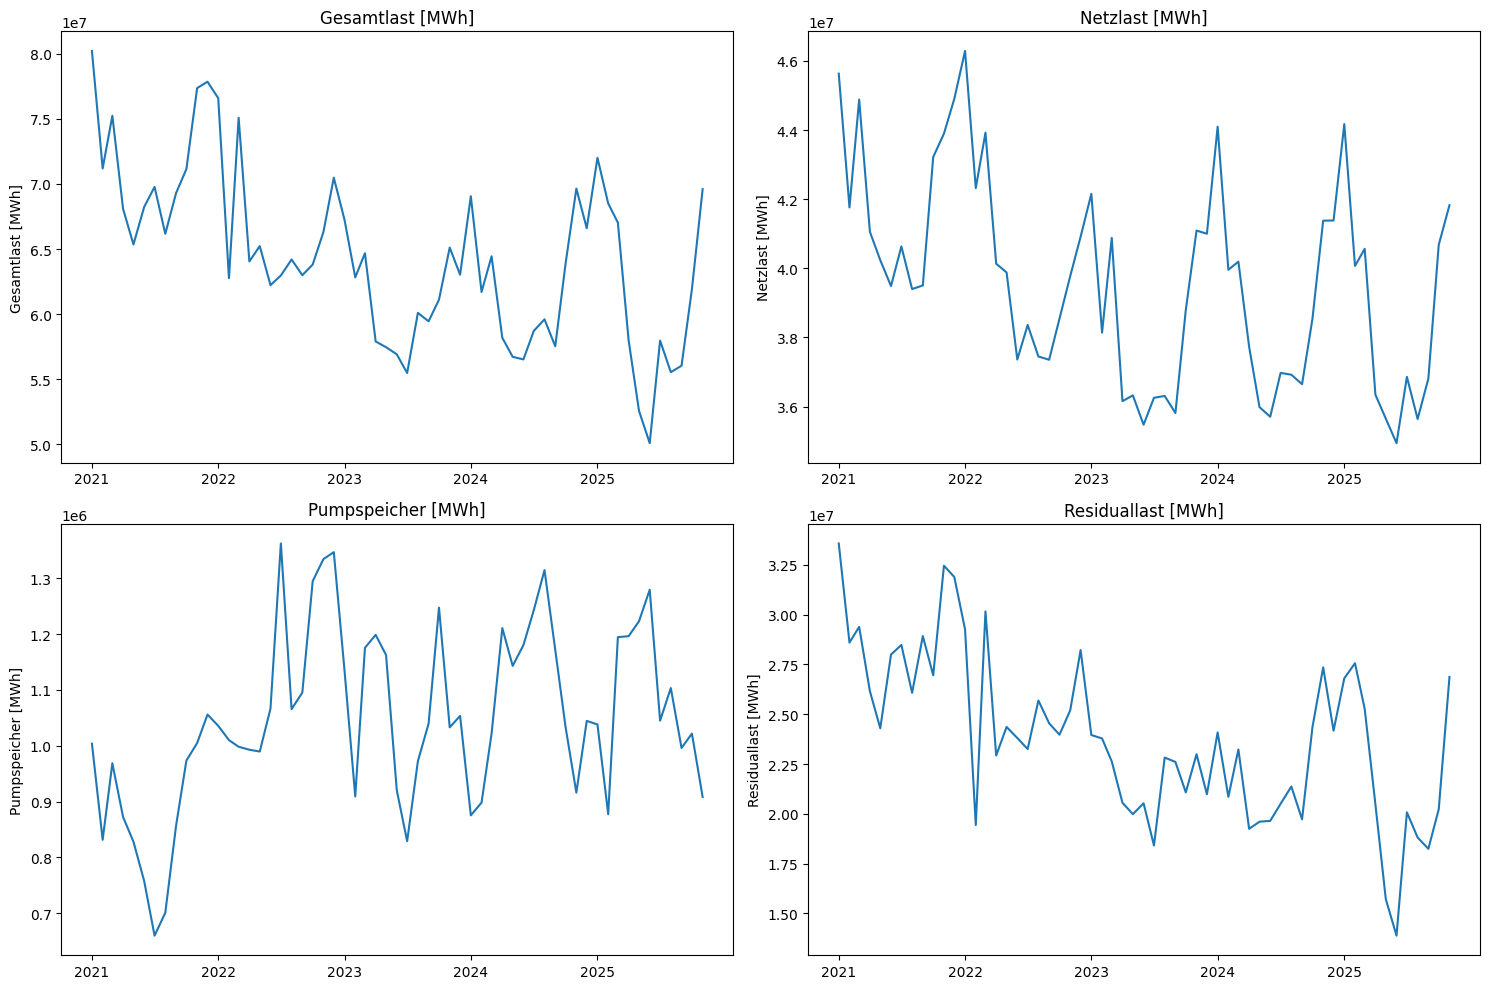

In [10]:
tickLabels = verbrauch['Datum von'].dt.year.unique()
tickLocations = [pd.to_datetime(f'{year}-01-01') for year in unique_years]
tickLabels = unique_years

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
ax = ax.flatten()

plotCols = verbrauch.columns.drop(["Datum von", "Datum bis", "Netzlast inkl. Pumpspeicher [MWh]"])

for i, col in enumerate(plotCols):
  sns.lineplot(data=verbrauch, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")
  ax[i].set_xticks(tickLocations, tickLabels)

plt.tight_layout()
plt.show()

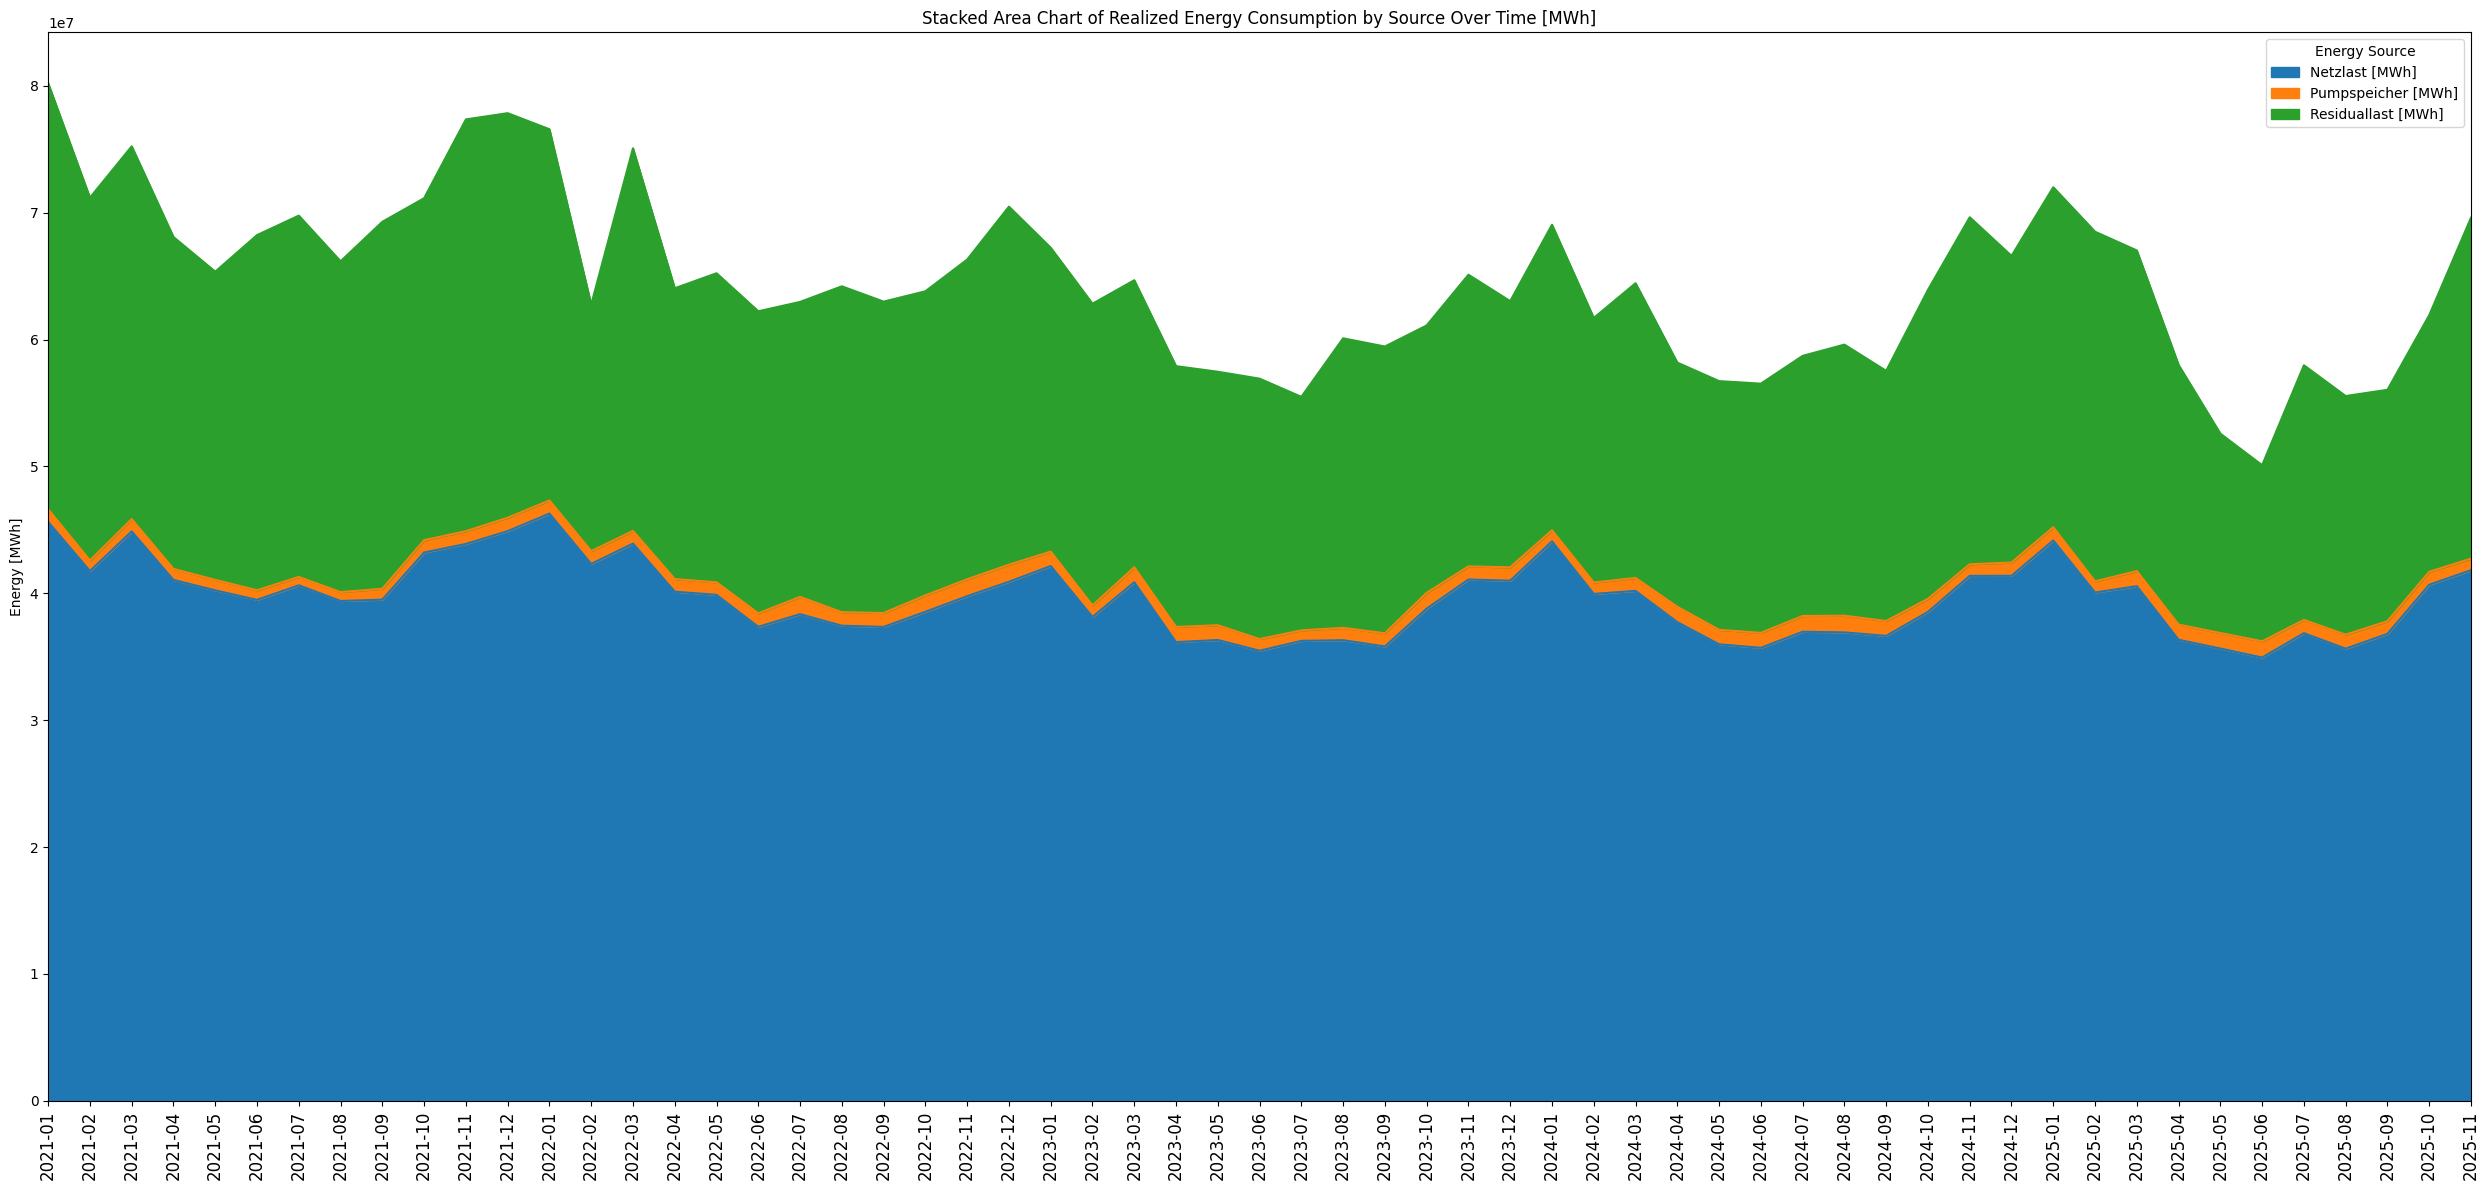

In [11]:
verbrauchPlotDf = verbrauch.set_index("Datum von")
stackCols = verbrauchPlotDf.columns.drop(["Datum bis", "Gesamtlast [MWh]", "Netzlast inkl. Pumpspeicher [MWh]"])

fig, ax = plt.subplots(figsize=(25, 12))
verbrauchPlotDf[stackCols].plot(kind="area", stacked=True, ax=ax)

allLabels = verbrauchPlotDf.index.strftime("%Y-%m")
allLocations = [pd.to_datetime(f"{label}-01") for label in allLabels]

ax.set_xticks(allLocations)
ax.set_xticklabels(allLabels, rotation=90, ha='center', fontsize=12)
ax.set_title('Stacked Area Chart of Realized Energy Consumption by Source Over Time [MWh]')
ax.set_ylabel('Energy [MWh]')
ax.set_xlabel('')
ax.legend(title='Energy Source', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Utilisation

In [12]:
percentDf = pd.DataFrame()
percentDf['Datum von'] = erzeugung['Datum von'].copy()
percentDf['Datum bis'] = erzeugung['Datum bis'].copy()

cols = instEnergy.columns[2:]

for i, col in enumerate(cols):
  percentDf[f"{col}_util%"] = round((erzeugung.iloc[:, 2+i] / instEnergy[col]) * 100, 2)

percentDf = percentDf.replace([np.nan, np.inf, -np.inf], 0)

percentDf = percentDf.rename(columns=lambda x: x.replace(" [MWh]", ""))

percentDf.head()

,Datum von,Datum bis,Gesamtkapazität_util%,Biomasse_util%,Wasserkraft_util%,Wind Offshore_util%,Wind Onshore_util%,Photovoltaik_util%,Sonstige Erneuerbare_util%,Kernenergie_util%,Braunkohle_util%,Steinkohle_util%,Erdgas_util%,Pumpspeicher_util%,Sonstige Konventionelle_util%
0,2021-01-01,2021-02-01,43.75,55.55,0.0,0.0,22.73,1.60,0.0,0.0,0.0,0.0,30.69,0.0,0.0
1,2021-02-01,2021-03-01,42.90,53.91,0.0,0.0,23.14,5.80,0.0,0.0,0.0,0.0,29.62,0.0,0.0
2,2021-03-01,2021-04-01,42.16,54.42,0.0,0.0,22.39,10.89,0.0,0.0,0.0,0.0,27.79,0.0,0.0
3,2021-04-01,2021-05-01,40.51,54.43,0.0,0.0,19.70,14.91,0.0,0.0,0.0,0.0,24.29,0.0,0.0
4,2021-05-01,2021-06-01,36.73,54.87,0.0,0.0,21.75,15.63,0.0,0.0,0.0,0.0,15.10,0.0,0.0


In [13]:
changeToPrevMonthDf = pd.DataFrame()
changeToPrevMonthDf['Datum von'] = percentDf['Datum von'].copy()
changeToPrevMonthDf['Datum bis'] = percentDf['Datum bis'].copy()

percent_columns = [col for col in percentDf.columns if 'util%' in col]

for col in percent_columns:
  changeToPrevMonthDf[f"{col}_delta%"] = round(percentDf[col].pct_change() * 100, 2)

changeToPrevMonthDf = changeToPrevMonthDf.fillna(0)

changeToPrevMonthDf = changeToPrevMonthDf.replace([np.inf, -np.inf], 0)

changeToPrevMonthDf = changeToPrevMonthDf.rename(columns=lambda x: x.replace("_util%", ""))

changeToPrevMonthDf.head()

,Datum von,Datum bis,Gesamtkapazität_delta%,Biomasse_delta%,Wasserkraft_delta%,Wind Offshore_delta%,Wind Onshore_delta%,Photovoltaik_delta%,Sonstige Erneuerbare_delta%,Kernenergie_delta%,Braunkohle_delta%,Steinkohle_delta%,Erdgas_delta%,Pumpspeicher_delta%,Sonstige Konventionelle_delta%
0,2021-01-01,2021-02-01,0.00,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0
1,2021-02-01,2021-03-01,-1.94,-2.95,0.0,0.0,1.80,262.50,0.0,0.0,0.0,0.0,-3.49,0.0,0.0
2,2021-03-01,2021-04-01,-1.72,0.95,0.0,0.0,-3.24,87.76,0.0,0.0,0.0,0.0,-6.18,0.0,0.0
3,2021-04-01,2021-05-01,-3.91,0.02,0.0,0.0,-12.01,36.91,0.0,0.0,0.0,0.0,-12.59,0.0,0.0
4,2021-05-01,2021-06-01,-9.33,0.81,0.0,0.0,10.41,4.83,0.0,0.0,0.0,0.0,-37.83,0.0,0.0


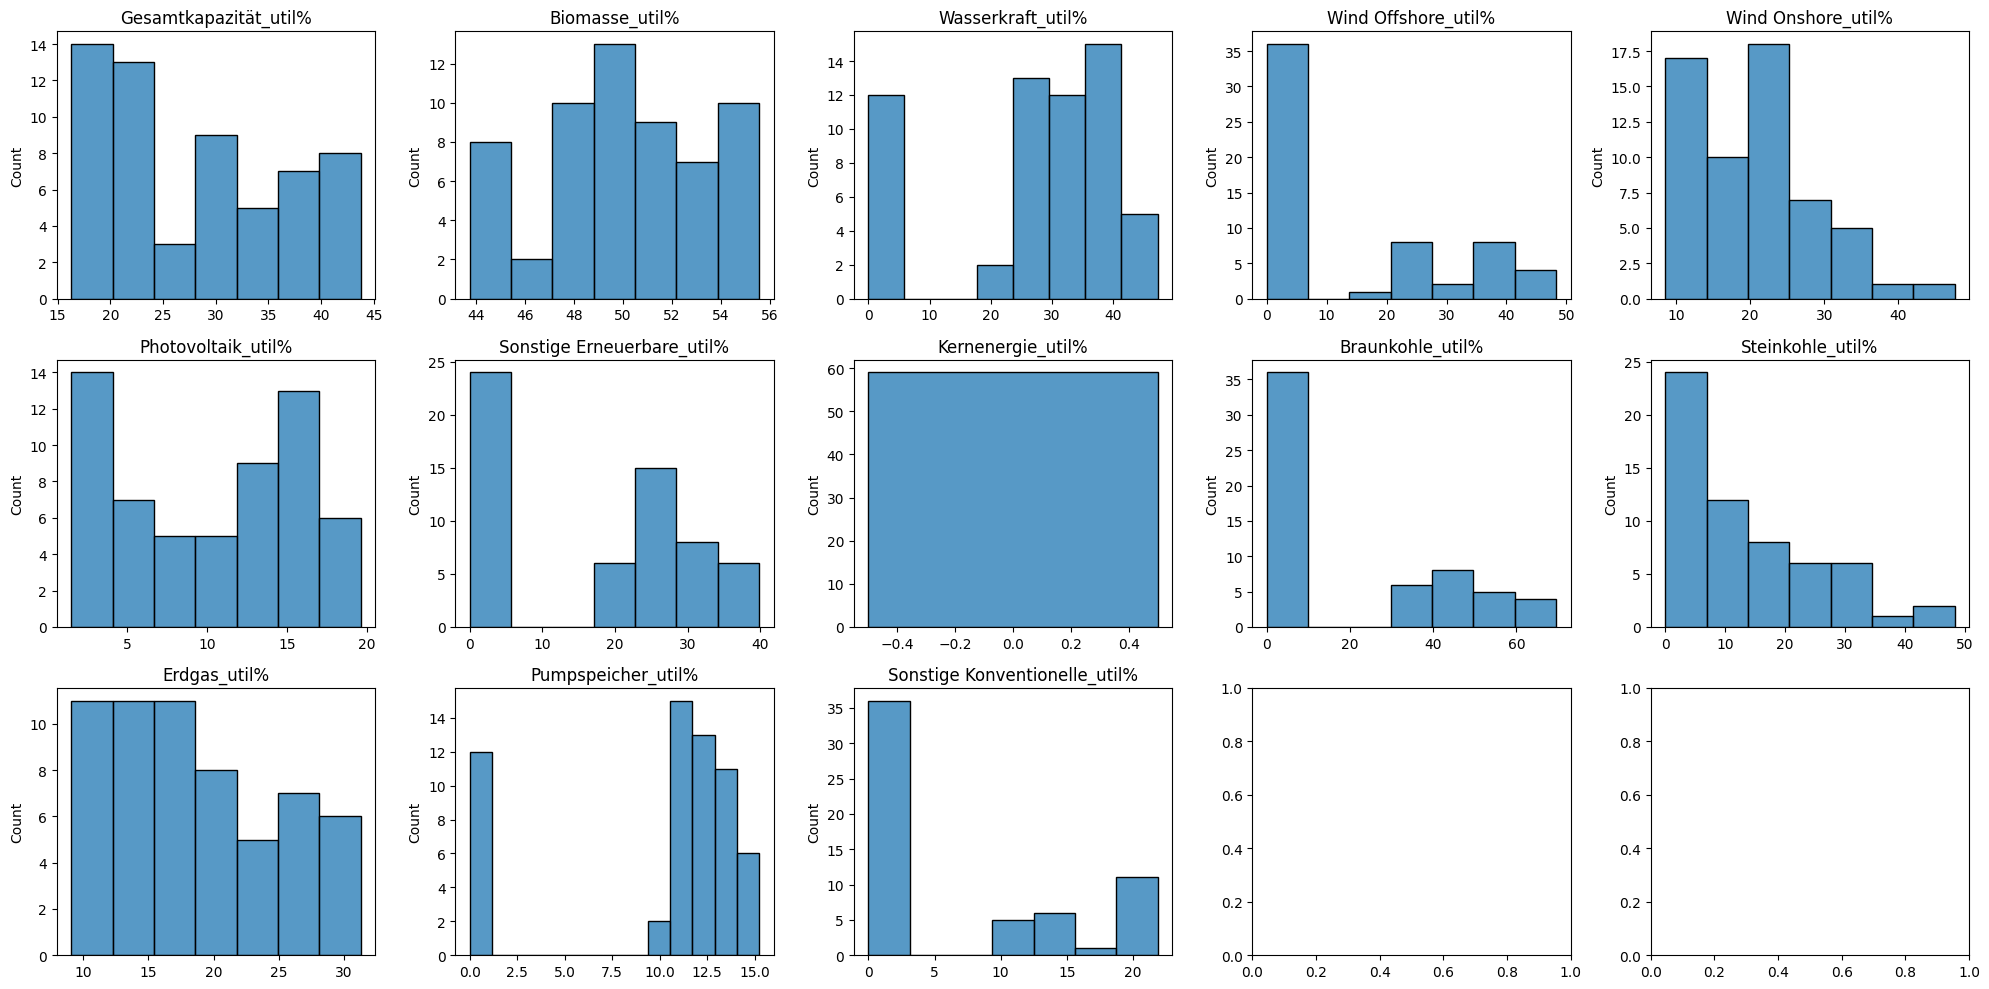

In [14]:
fig, ax = plt.subplots(3, 5, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(percent_columns):
  sns.histplot(data=percentDf, x=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

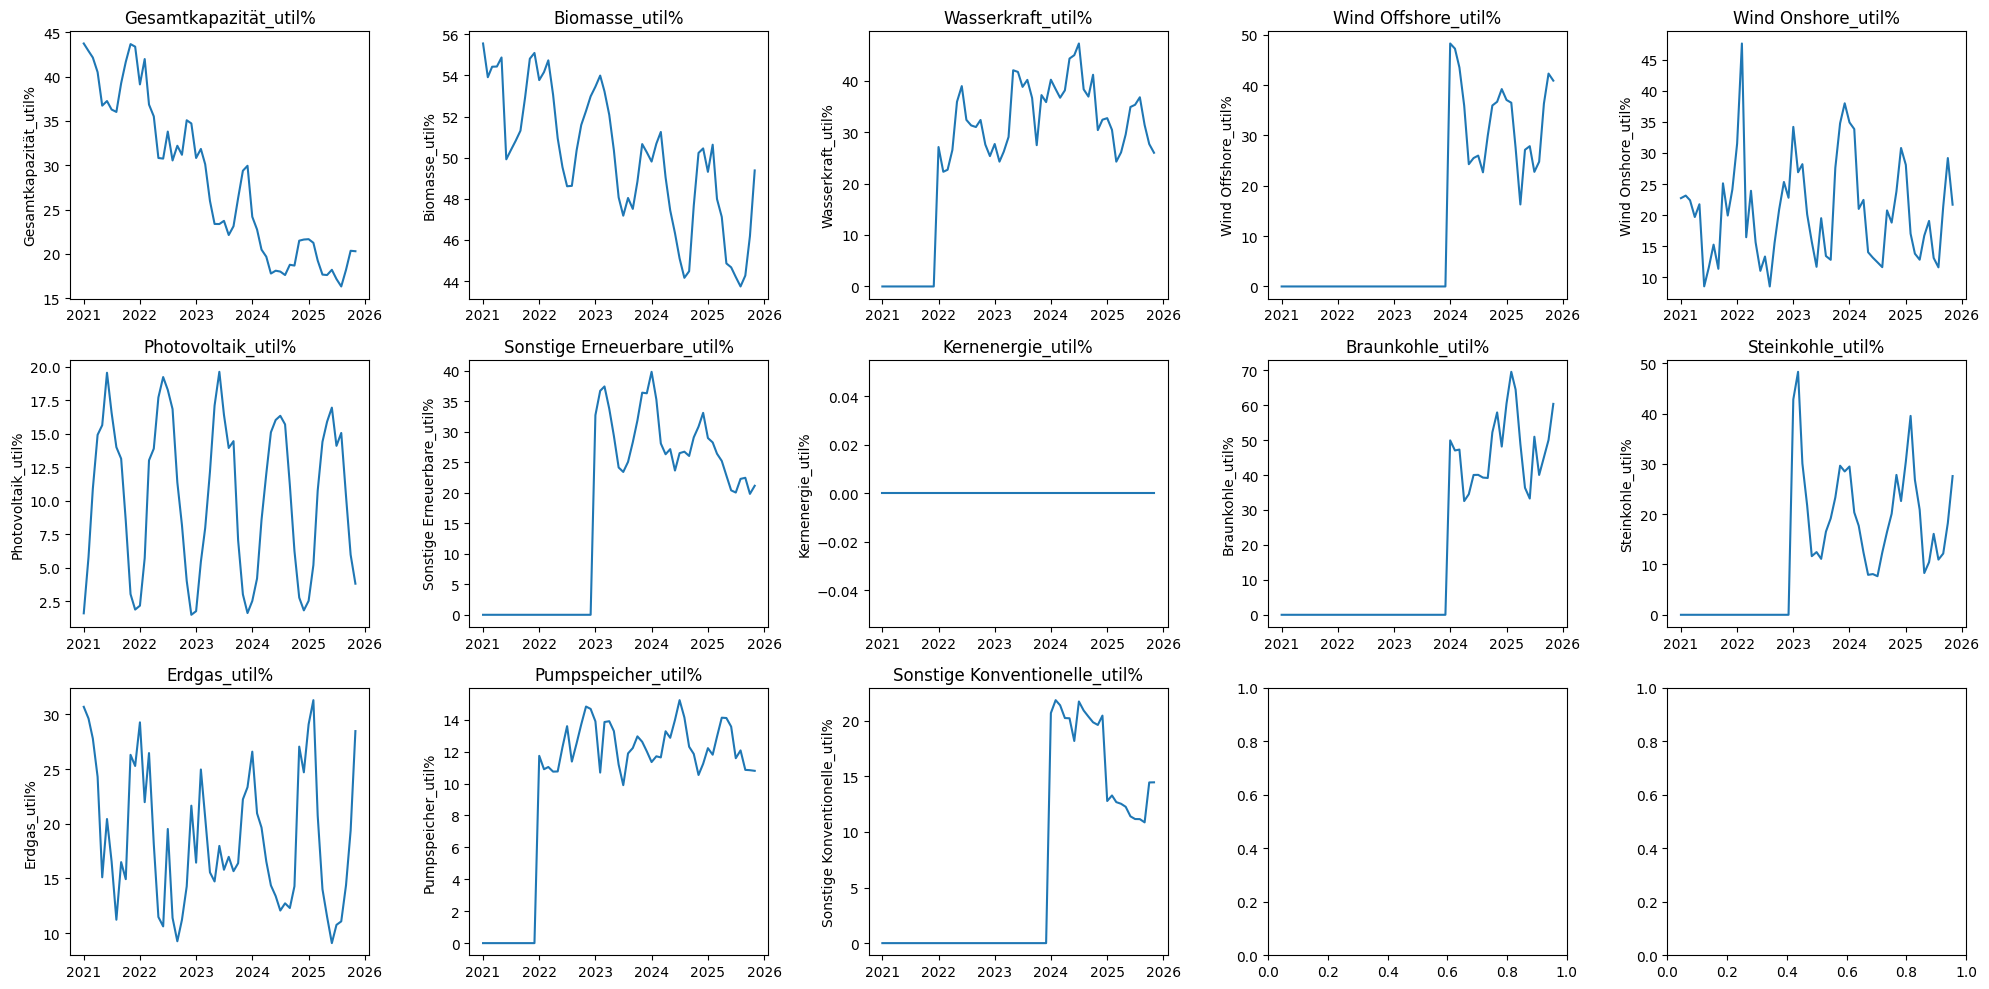

In [15]:
fig, ax = plt.subplots(3, 5, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(percent_columns):
  sns.lineplot(data=percentDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")
  ax[i].set_ylabel(f"{col}")

plt.tight_layout()
plt.show()

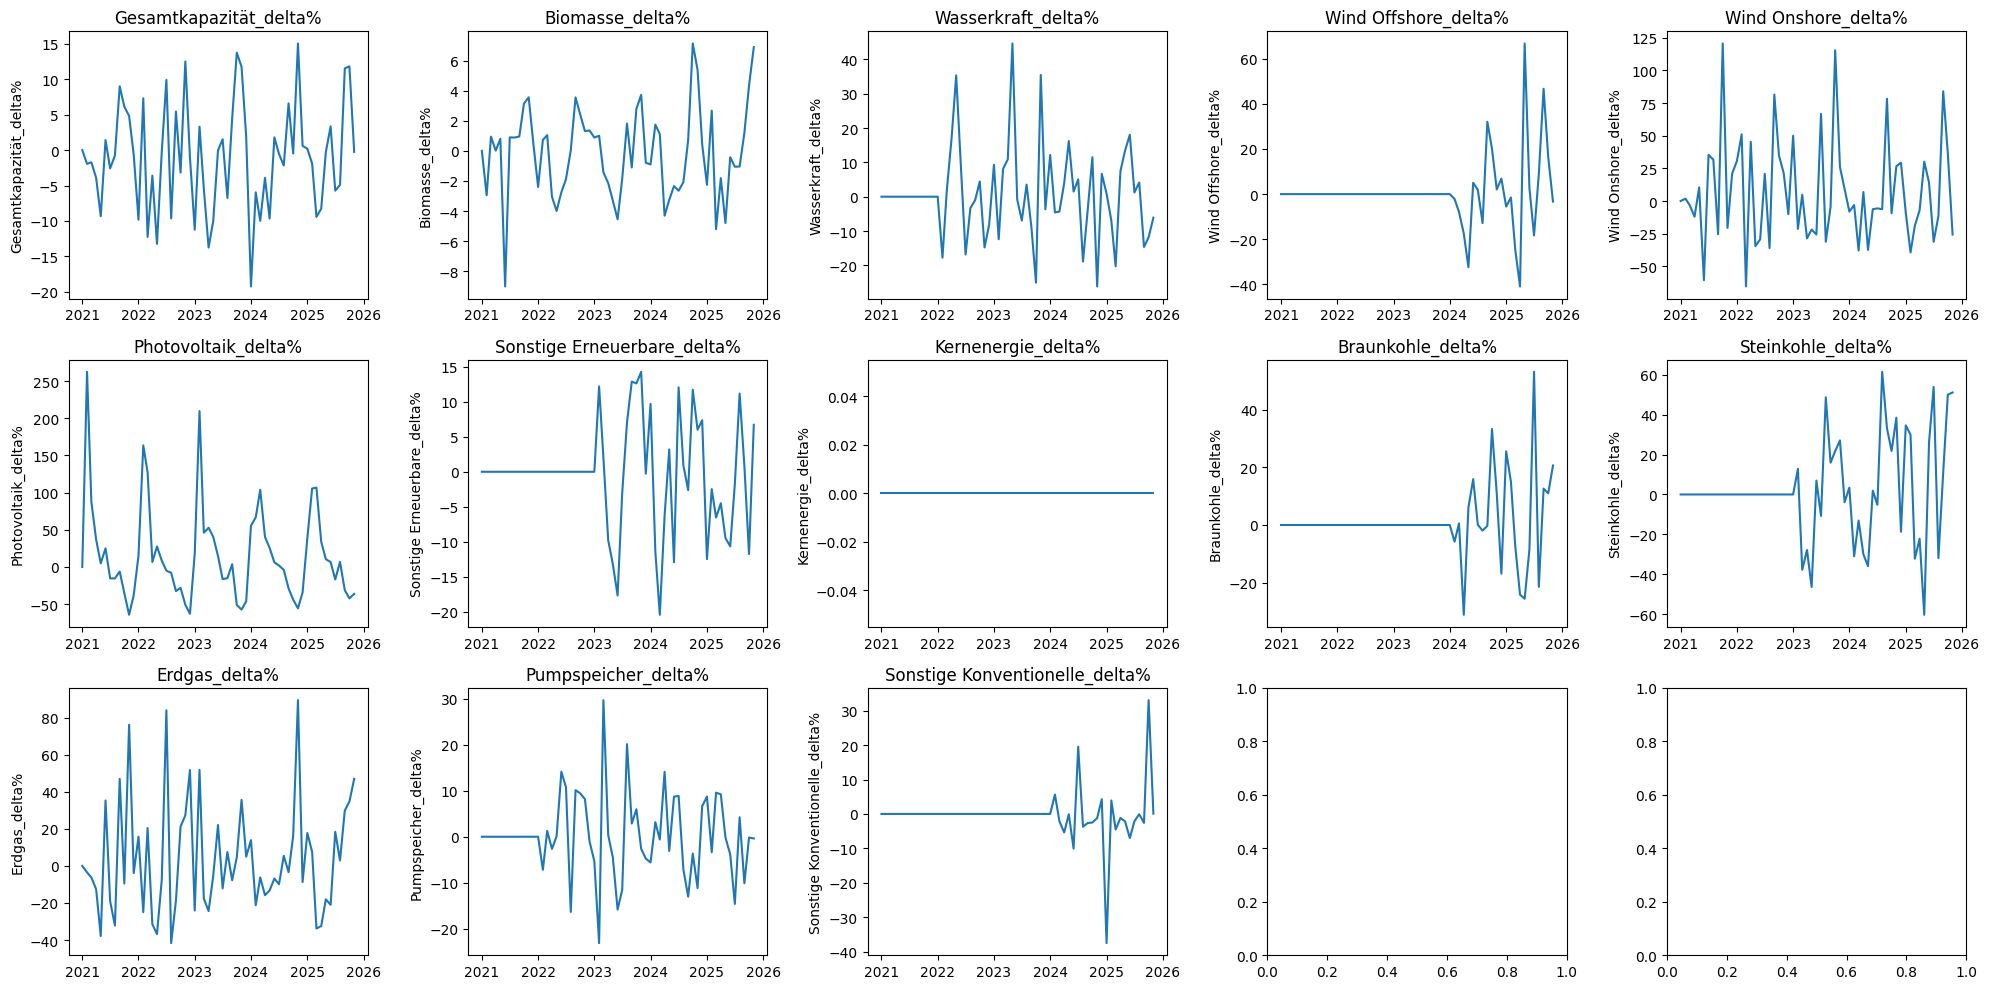

In [16]:
fig, ax = plt.subplots(3, 5, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(changeToPrevMonthDf.columns[2:]):
  sns.lineplot(data=changeToPrevMonthDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")
  ax[i].set_ylabel(f"{col}")

plt.tight_layout()
plt.show()

In [17]:
verbrauchPercentDf = verbrauch[["Datum von", "Datum bis", "Gesamtlast [MWh]"]].copy()

for col in verbrauch.columns[3:]:
  verbrauchPercentDf[f"{col}_cons%"] = round(verbrauch[col] / verbrauch['Gesamtlast [MWh]'] * 100, 2)

verbrauchPercentDf = verbrauchPercentDf.rename(columns=lambda x: x.replace(" [MWh]", ""))

verbrauchPercentDf.head()

,Datum von,Datum bis,Gesamtlast,Netzlast_cons%,Netzlast inkl. Pumpspeicher_cons%,Pumpspeicher_cons%,Residuallast_cons%
0,2021-01-01,2021-02-01,80212151.13,56.89,58.14,1.25,41.86
1,2021-02-01,2021-03-01,71188575.25,58.66,59.83,1.17,40.17
2,2021-03-01,2021-04-01,75235874.25,59.65,60.94,1.29,39.06
3,2021-04-01,2021-05-01,68086182.00,60.30,61.58,1.28,38.42
4,2021-05-01,2021-06-01,65356819.25,61.56,62.83,1.27,37.17


In [18]:
verbrauchChangeDf = pd.DataFrame()
verbrauchChangeDf["Datum von"] = verbrauch['Datum von'].copy()
verbrauchChangeDf["Datum bis"] = verbrauch['Datum bis'].copy()

changeCols = [col for col in verbrauch.columns if "[MWh]" in col]

verbrauchChangeDf[changeCols] = round(verbrauch[changeCols].pct_change() * 100, 2)
verbrauchChangeDf = verbrauchChangeDf.fillna(0)
verbrauchChangeDf.head()

,Datum von,Datum bis,Gesamtlast [MWh],Netzlast [MWh],Netzlast inkl. Pumpspeicher [MWh],Pumpspeicher [MWh],Residuallast [MWh]
0,2021-01-01,2021-02-01,0.00,0.00,0.00,0.00,0.00
1,2021-02-01,2021-03-01,-11.25,-8.49,-8.67,-17.16,-14.83
2,2021-03-01,2021-04-01,5.69,7.48,7.65,16.50,2.76
3,2021-04-01,2021-05-01,-9.50,-8.52,-8.55,-9.95,-10.98
4,2021-05-01,2021-06-01,-4.01,-2.00,-2.06,-5.07,-7.13


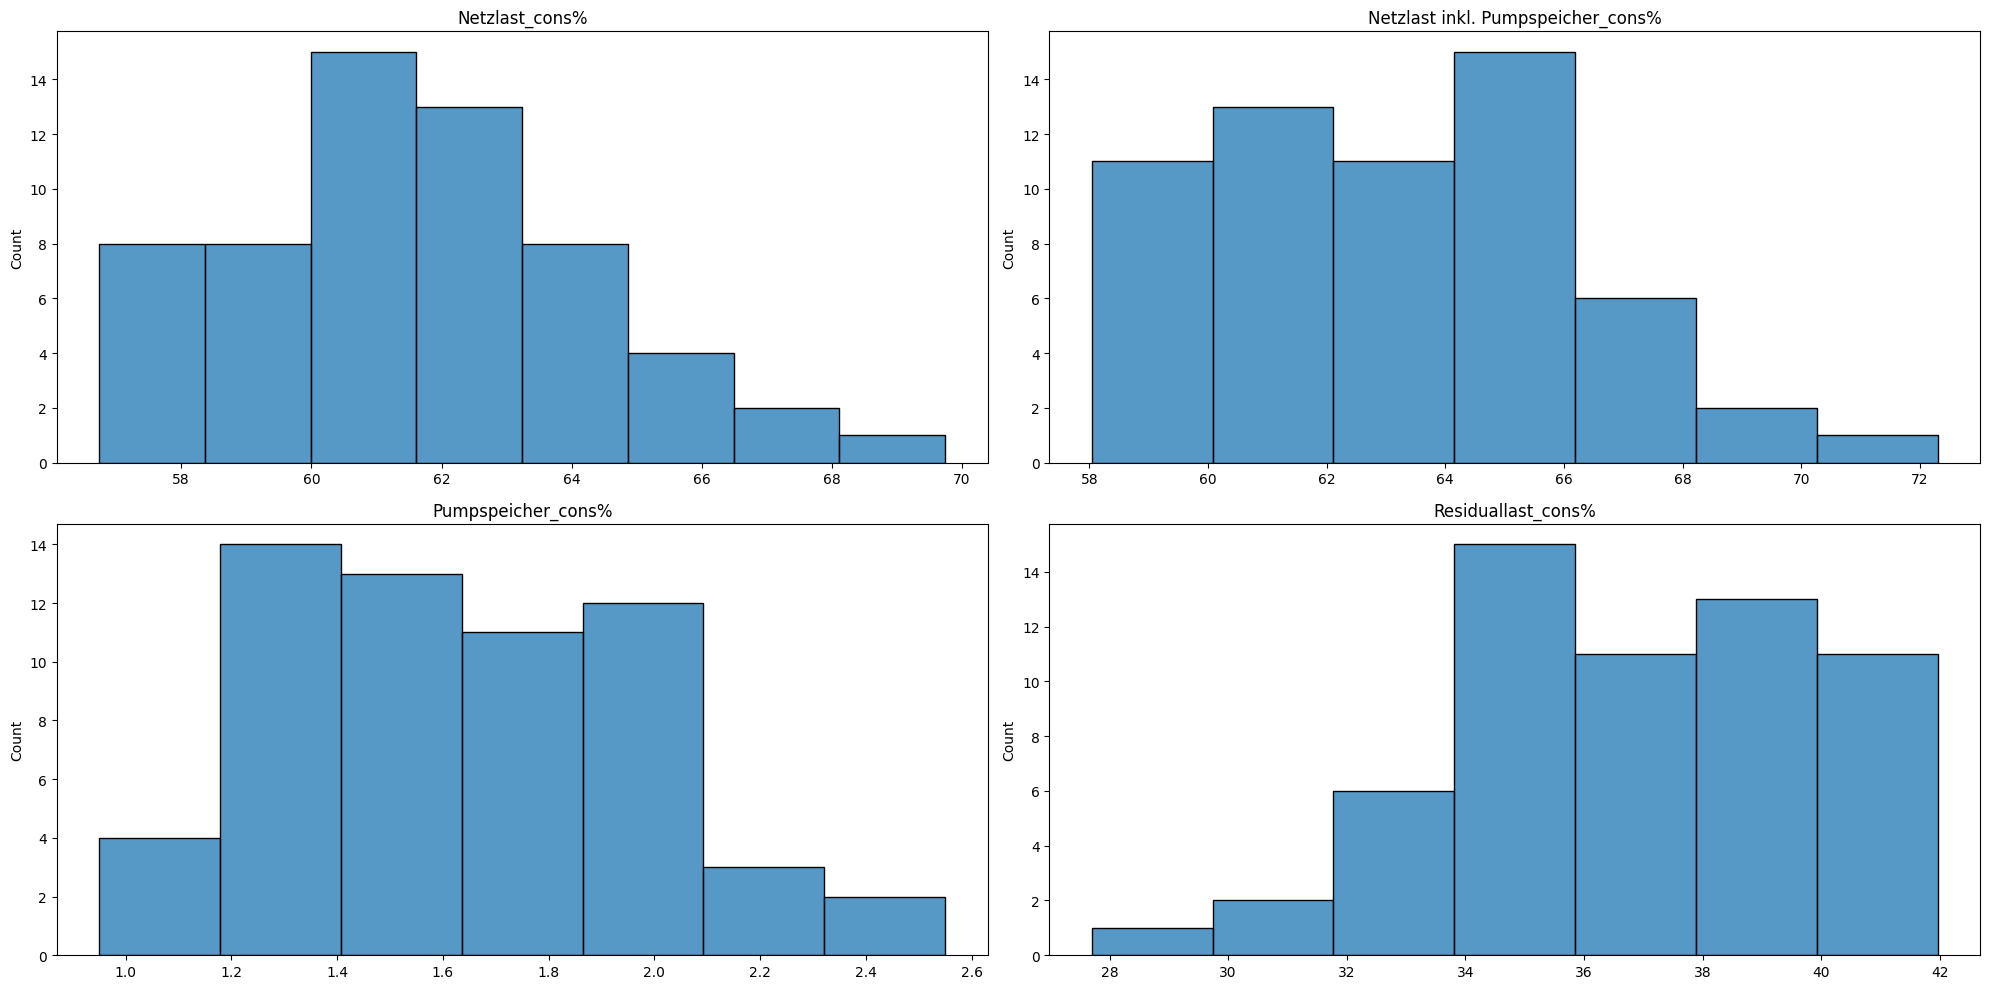

In [19]:
cons_percent_columns = [col for col in verbrauchPercentDf.columns if "cons%" in col]

fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(cons_percent_columns):
  sns.histplot(data=verbrauchPercentDf, x=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

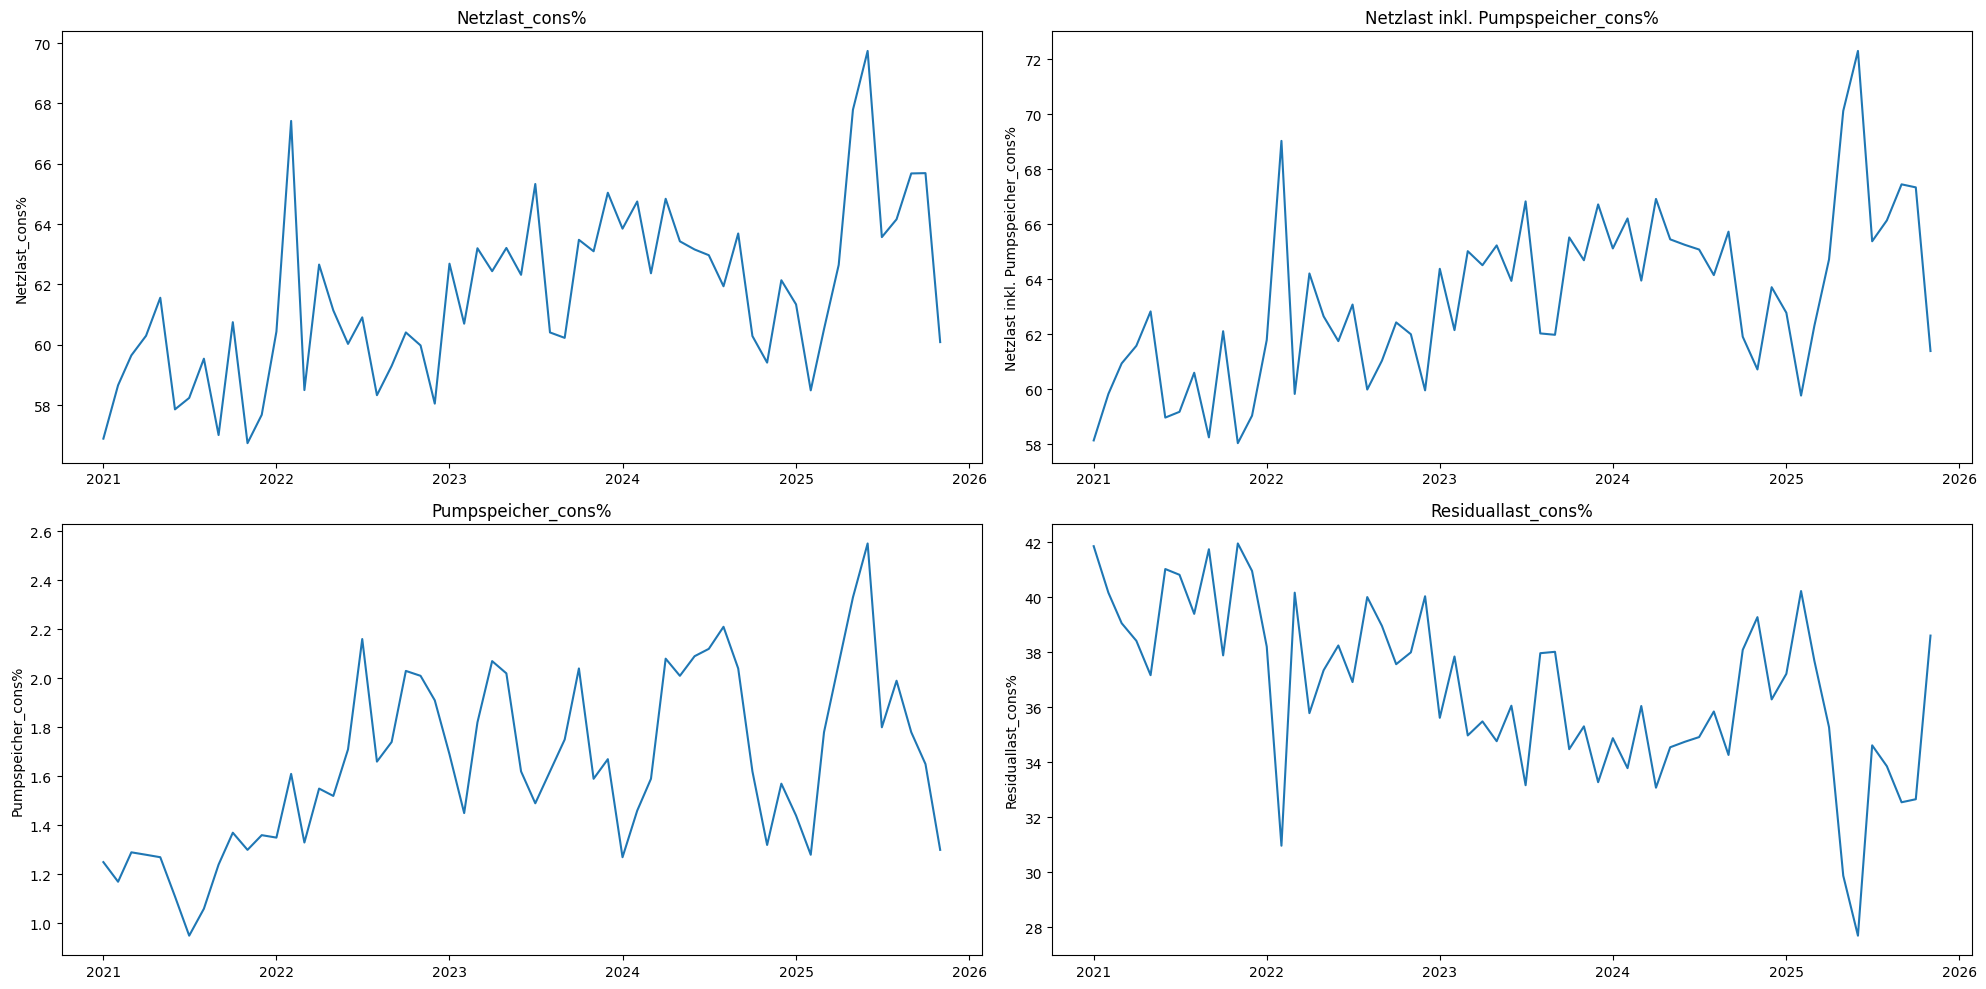

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(cons_percent_columns):
  sns.lineplot(data=verbrauchPercentDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

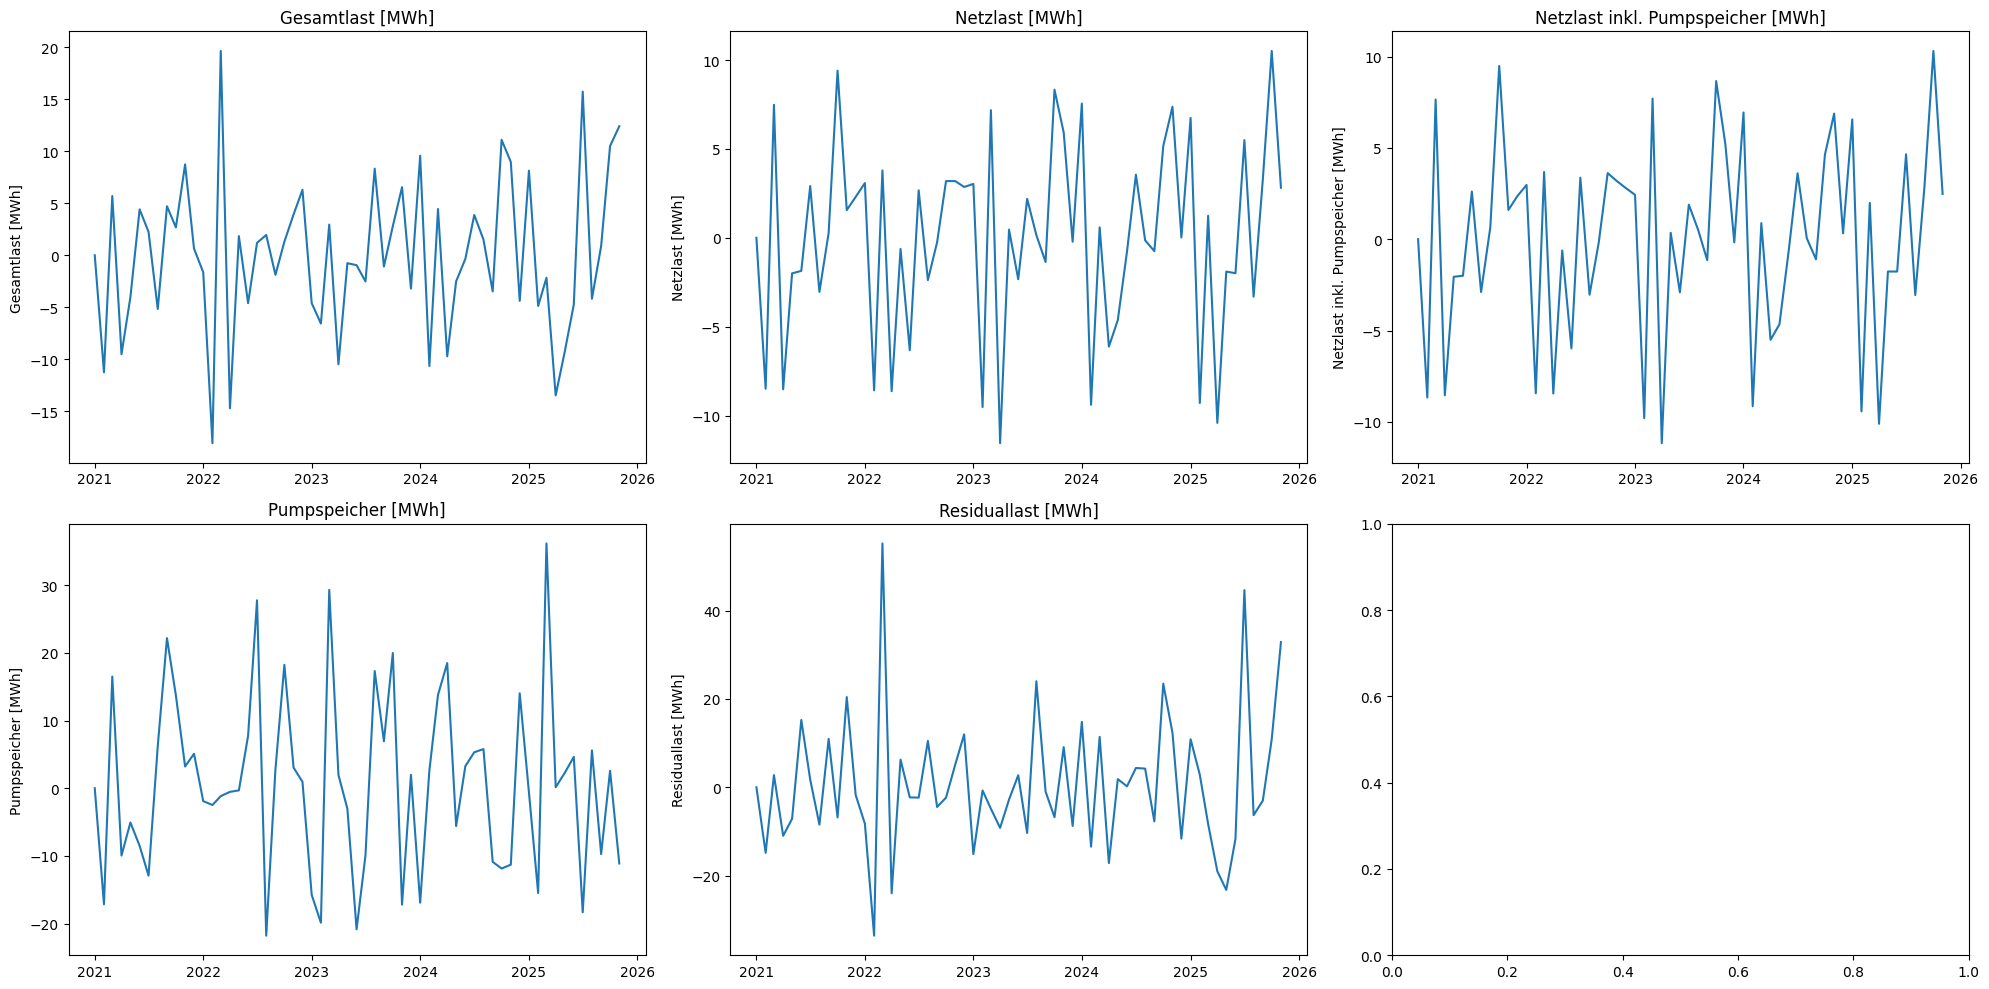

In [21]:
consChangeCols = [col for col in verbrauchChangeDf.columns if "[MWh]" in col]

fig, ax = plt.subplots(2, 3, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(consChangeCols):
  sns.lineplot(data=verbrauchChangeDf, x="Datum von", y=col, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel("")

plt.tight_layout()
plt.show()

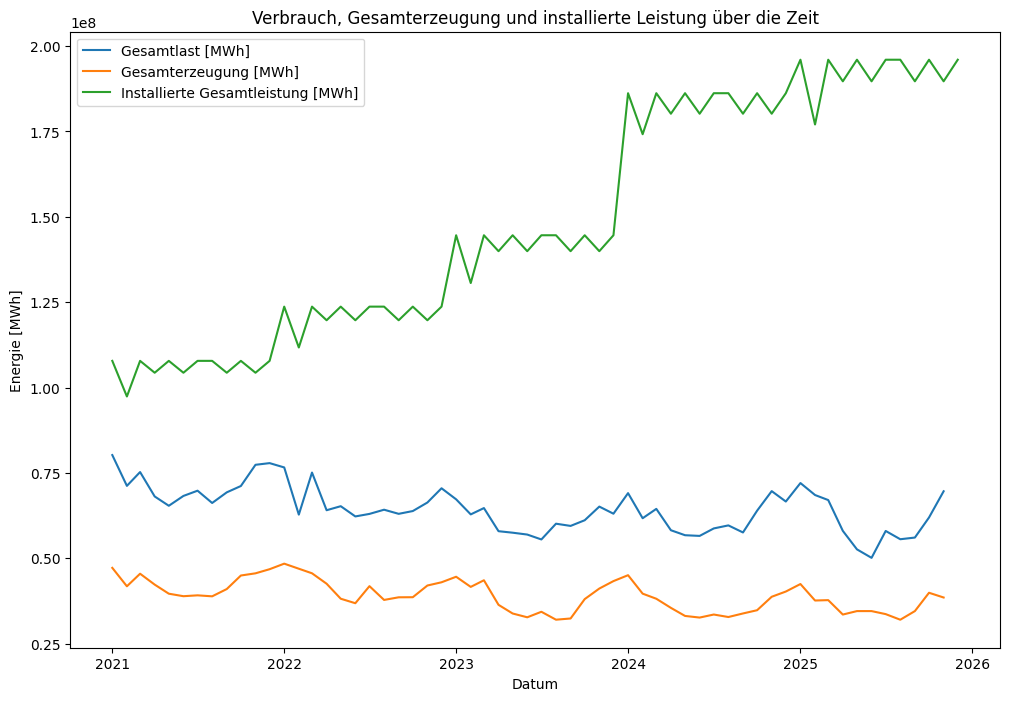

In [22]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=verbrauch, x="Datum von", y="Gesamtlast [MWh]", label="Gesamtlast [MWh]")
sns.lineplot(data=erzeugung, x="Datum von", y="Gesamterzeugung [MWh]", label="Gesamterzeugung [MWh]")
sns.lineplot(data=instEnergy, x="Datum von", y="Gesamtkapazität [MWh]", label="Installierte Gesamtleistung [MWh]")


plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Verbrauch, Gesamterzeugung und installierte Leistung über die Zeit")
plt.legend(loc='best')

plt.show()

In [23]:
rollingErzeugung = erzeugung['Gesamterzeugung [MWh]'].rolling(window=6, center=True, min_periods=3).mean()
rollingVerbrauch = verbrauch['Gesamtlast [MWh]'].rolling(window=6, center=True, min_periods=3).mean()

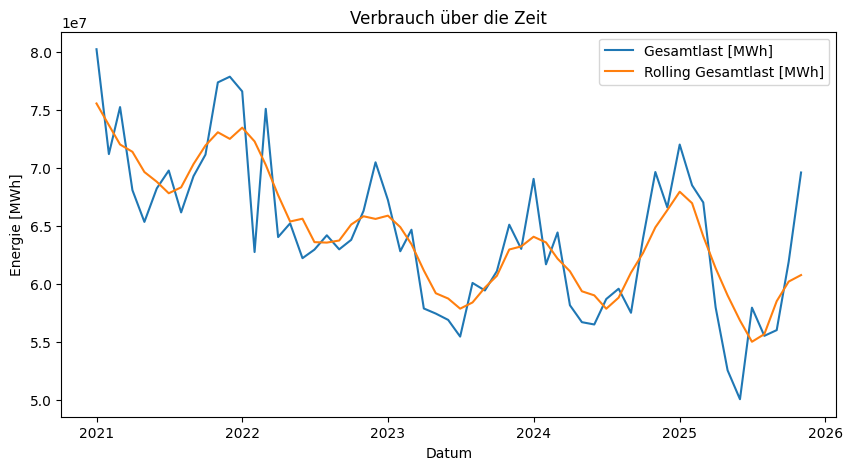

In [24]:
plt.figure(figsize=(10, 5))

sns.lineplot(data=verbrauch, x="Datum von", y="Gesamtlast [MWh]", label="Gesamtlast [MWh]")
sns.lineplot(x=verbrauch['Datum von'], y=rollingVerbrauch, label="Rolling Gesamtlast [MWh]")

plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Verbrauch über die Zeit")
plt.legend(loc='best')

plt.show()

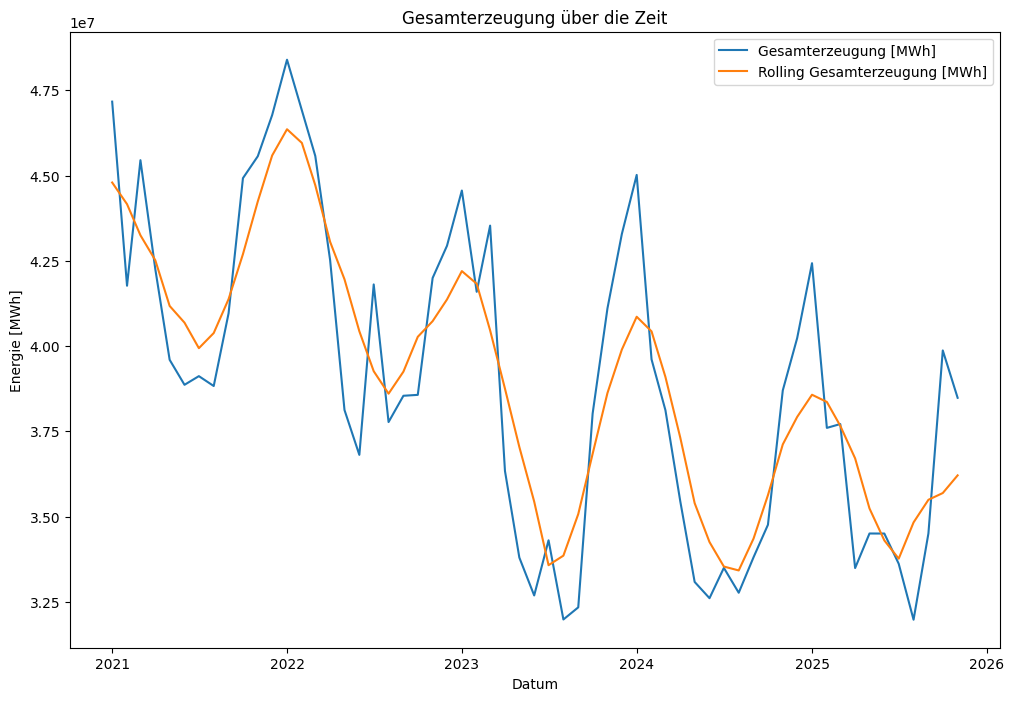

In [25]:
plt.figure(figsize=(12, 8))

sns.lineplot(data=erzeugung, x="Datum von", y="Gesamterzeugung [MWh]", label="Gesamterzeugung [MWh]")
sns.lineplot(x=erzeugung['Datum von'], y=rollingErzeugung, label="Rolling Gesamterzeugung [MWh]")

plt.xlabel("Datum")
plt.ylabel("Energie [MWh]")
plt.title("Gesamterzeugung über die Zeit")
plt.legend(loc='best')

plt.show()

Renewable Share

In [26]:
ee = ["Biomasse [MWh]", "Wasserkraft [MWh]", "Wind Offshore [MWh]", "Wind Onshore [MWh]", "Photovoltaik [MWh]", "Sonstige Erneuerbare [MWh]"]

erzeugung.insert(3, "Gesamt Erneuerbare [MWh]", erzeugung[ee].sum(axis=1))

erzeugung.head()

,Datum von,Datum bis,Gesamterzeugung [MWh],Gesamt Erneuerbare [MWh],Biomasse [MWh],Wasserkraft [MWh],Wind Offshore [MWh],Wind Onshore [MWh],Photovoltaik [MWh],Sonstige Erneuerbare [MWh],Kernenergie [MWh],Braunkohle [MWh],Steinkohle [MWh],Erdgas [MWh],Pumpspeicher [MWh],Sonstige Konventionelle [MWh]
0,2021-01-01,2021-02-01,47170005.5,16591824.00,3390654.25,992324.50,2263541.25,9190255.25,600445.75,154603.00,5925379.00,10260437.50,5111958.25,7292294.75,797113.50,1190998.50
1,2021-02-01,2021-03-01,41770396.5,17330781.00,2972072.25,1067784.75,2743174.50,8451315.00,1966106.50,130328.00,5343534.75,7686818.75,3350323.25,6358551.00,680576.50,1019811.25
2,2021-03-01,2021-04-01,45452515.0,20058964.00,3321780.50,1096885.50,2356745.00,9052932.75,4084762.00,145858.25,5502068.00,7844513.50,3502914.00,6603361.75,770015.25,1170678.50
3,2021-04-01,2021-05-01,42260696.0,19254264.75,3215143.75,1028506.25,1775864.25,7709987.75,5411394.25,113368.50,5145542.75,7086525.50,3452755.50,5587178.00,656823.00,1077606.50
4,2021-05-01,2021-06-01,39597867.0,20948014.00,3348917.75,1547943.00,1287883.50,8792241.50,5861740.75,109287.50,5277141.25,5706664.75,2393617.25,3589174.50,571920.75,1111334.50


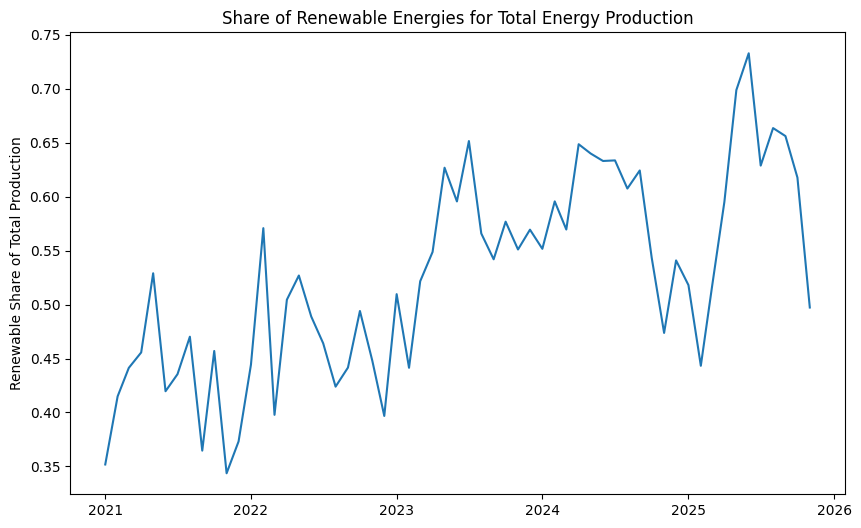

In [27]:
renewableShare = erzeugung.copy()

renewableShare["Renewable Share"] = renewableShare["Gesamt Erneuerbare [MWh]"] / renewableShare["Gesamterzeugung [MWh]"]

plt.figure(figsize=(10, 6))

sns.lineplot(data=renewableShare, x="Datum von", y="Renewable Share")

plt.xlabel("")
plt.ylabel("Renewable Share of Total Production")
plt.title("Share of Renewable Energies for Total Energy Production")

plt.show()